# VAE Evaluation — CC1-Only Design (CC2 drift scope)

Input: `models/vae_cc1.pt` + `vae_cc1_meta.pkl` and `data/processed/windows_cc1/*.npy`.
Evaluates on `cc1_test` (in-distribution) and `drift_cc2` (the sole drift set —
SC1/SC2 dropped from scope per project decision).

**Full metrics list, ordered by priority** (per the project's evaluation-design
discussion):
1. **PR-AUC** (primary) — the metric that actually matters under this severe
   class imbalance (<1% positive rate); ROC-AUC alone is demonstrably
   misleading here (see Step 2).
2. **F1 / Precision / Recall / FPR** at a leak-free operating threshold
   (co-primary — what a deployed system's behavior actually looks like).
3. **Oracle-ceiling analysis** — is the current threshold leaving performance
   on the table, or is the model itself the limit?
4. **Per-fault-type recall** (cpu / memory / pod-failure).
5. **Detection delay** — time from fault onset to first flagged window,
   directly relevant to the "real-time" claim and not measured anywhere
   before this notebook.
6. **KS-test drift characterization**.
7. **Consolidated summary dashboard** — the one table/figure suitable for
   direct inclusion in the results chapter.

Every threshold in this notebook is chosen from `cc1_val`'s unsupervised
behavior only — never from `cc1_test`/`drift_cc2` labels.

In [16]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pickle, json, os
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    precision_score, recall_score, f1_score, confusion_matrix,
)
from scipy import stats

BASE      = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3'
DATA_DIR  = os.path.join(BASE, 'data', 'processed', 'windows_cc1')
RAW_DIR   = os.path.join(BASE, 'data', 'processed')
MODEL_DIR = os.path.join(BASE, 'models')

DRIFT_SETS = ['drift_cc2']
ALL_SETS   = ['cc1_test'] + DRIFT_SETS

print('Paths configured.')

Paths configured.


## Step 1 — Load model + recompute anomaly scores

In [17]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, latent_dim):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, hidden1), nn.ReLU(), nn.Linear(hidden1, hidden2), nn.ReLU())
        self.fc_mu = nn.Linear(hidden2, latent_dim)
        self.fc_lv = nn.Linear(hidden2, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, hidden2), nn.ReLU(), nn.Linear(hidden2, hidden1), nn.ReLU(), nn.Linear(hidden1, input_dim))
    def encode(self, x):
        h = self.encoder(x); return self.fc_mu(h), torch.clamp(self.fc_lv(h), -10, 10)
    def decode(self, z): return self.decoder(z)
    @torch.no_grad()
    def anomaly_score(self, x):
        self.eval(); mu, _ = self.encode(x); return ((self.decode(mu) - x) ** 2).mean(dim=1)

meta = pickle.load(open(os.path.join(MODEL_DIR, 'vae_cc1_meta.pkl'), 'rb'))
print('Model metadata:', {k: v for k, v in meta.items() if k not in ('beta_search', 'ablation')})

model = VAE(meta['input_dim'], meta['hidden1'], meta['hidden2'], meta['latent_dim'])
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'vae_cc1.pt'), map_location='cpu'))
model.eval()

CLIP = meta['clip']
X, y, ft, mse = {}, {}, {}, {}
for name in ['cc1_train', 'cc1_val'] + ALL_SETS:
    Xr = np.load(os.path.join(DATA_DIR, f'X_{name}.npy'))
    X[name] = np.clip(Xr, -CLIP, CLIP).astype(np.float32)
    y[name] = np.load(os.path.join(DATA_DIR, f'y_{name}.npy'))
    ft[name] = np.load(os.path.join(DATA_DIR, f'ft_{name}.npy'), allow_pickle=True)
    mse[name] = model.anomaly_score(torch.from_numpy(X[name])).numpy()
    print(f'  {name:10s}: {len(y[name]):>7,} windows  |  anomalies: {int(y[name].sum()):,}  ({y[name].mean()*100:.2f}%)')

assert abs(mse['cc1_train'].mean() - meta['mu_train']) < 1e-3
print(f'\nRecomputed cc1_train MSE matches saved meta baseline. Good.')

Model metadata: {'input_dim': 26, 'hidden1': 64, 'hidden2': 32, 'latent_dim': 32, 'beta_max': 0.01, 'clip': 20.0, 'mu_train': 0.022176498547196388, 'sigma_train': 0.0320117361843586}
  cc1_train : 154,198 windows  |  anomalies: 0  (0.00%)
  cc1_val   :  21,573 windows  |  anomalies: 0  (0.00%)
  cc1_test  :  44,185 windows  |  anomalies: 256  (0.58%)
  drift_cc2 :  76,977 windows  |  anomalies: 720  (0.94%)

Recomputed cc1_train MSE matches saved meta baseline. Good.


## Step 2 — Threshold-free quality: PR-AUC (primary) vs. ROC-AUC

**Both are plotted, not just reported as numbers** — the PR curve is the one
that matters most here; the ROC curve is included for completeness but with
an explicit warning where it's misleading.

set            PR-AUC (primary)   ROC-AUC   n_anom  anom_rate  no-skill PR-AUC  PR-AUC lift
cc1_test                 0.6014    0.8763      256      0.58%           0.0058       103.8x
drift_cc2                0.4089    0.8812      720      0.94%           0.0094        43.7x


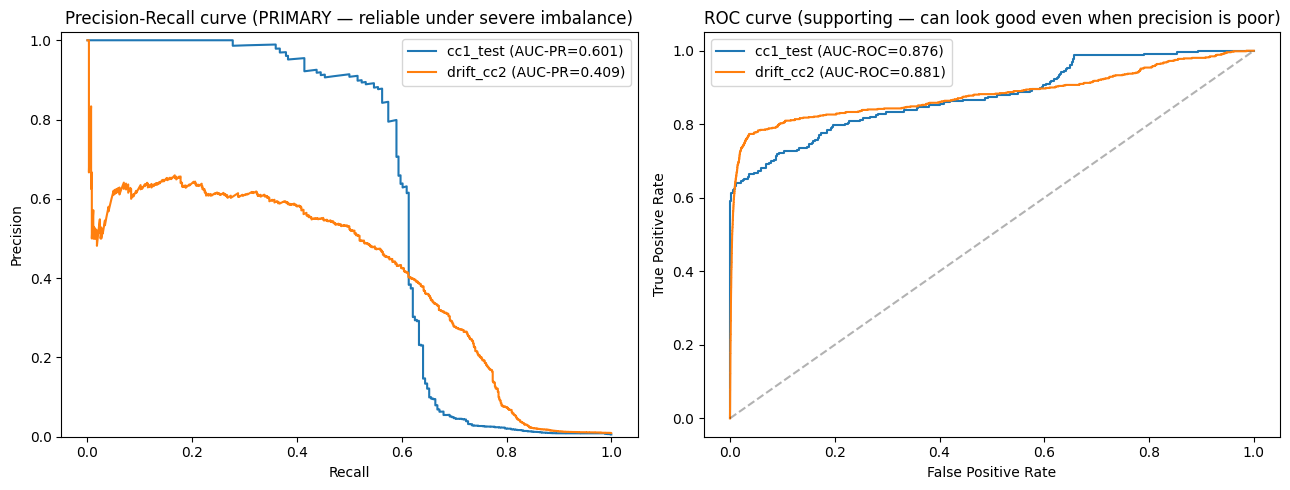

In [18]:
auc_results = {}
for name in ALL_SETS:
    auc_results[name] = {'auc_roc': roc_auc_score(y[name], mse[name]), 'auc_pr': average_precision_score(y[name], mse[name])}

print(f'{"set":12s} {"PR-AUC (primary)":>18s} {"ROC-AUC":>9s} {"n_anom":>8s} {"anom_rate":>10s} {"no-skill PR-AUC":>16s} {"PR-AUC lift":>12s}')
for name in ALL_SETS:
    base_rate = y[name].mean()
    lift = auc_results[name]['auc_pr'] / base_rate
    print(f'{name:12s} {auc_results[name]["auc_pr"]:18.4f} {auc_results[name]["auc_roc"]:9.4f} '
          f'{int(y[name].sum()):8,} {base_rate*100:9.2f}% {base_rate:16.4f} {lift:11.1f}x')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name in ALL_SETS:
    p, r, _ = precision_recall_curve(y[name], mse[name])
    axes[0].plot(r, p, label=f'{name} (AUC-PR={auc_results[name]["auc_pr"]:.3f})')
    fpr, tpr, _ = roc_curve(y[name], mse[name])
    axes[1].plot(fpr, tpr, label=f'{name} (AUC-ROC={auc_results[name]["auc_roc"]:.3f})')

axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall curve (PRIMARY — reliable under severe imbalance)')
axes[0].legend(); axes[0].set_ylim(0, 1.02)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC curve (supporting — can look good even when precision is poor)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_cc1_eval_pr_roc_curves.png'), dpi=120)
plt.show()

## Step 3 — Leak-free operating-point thresholds

In [19]:
val_p99 = float(np.percentile(mse['cc1_val'], 99))
k2 = meta['mu_train'] + 2 * meta['sigma_train']
k3 = meta['mu_train'] + 3 * meta['sigma_train']
THRESHOLDS = {'val_p99': val_p99, 'k=2': k2, 'k=3': k3}

for name, t in THRESHOLDS.items():
    fpr_on_val = (mse['cc1_val'] > t).mean()
    print(f'  {name:8s}: threshold={t:.5f}   flags {fpr_on_val*100:.2f}% of cc1_val (all normal) -> false-positive-rate estimate')

  val_p99 : threshold=0.09799   flags 1.00% of cc1_val (all normal) -> false-positive-rate estimate
  k=2     : threshold=0.08620   flags 1.31% of cc1_val (all normal) -> false-positive-rate estimate
  k=3     : threshold=0.11821   flags 0.65% of cc1_val (all normal) -> false-positive-rate estimate


## Step 4 — Precision / Recall / F1 / False-Positive-Rate at each operating point

FPR is now reported explicitly (previously only recoverable from the
confusion matrix) — it's the number that determines whether a deployed system
generates a usable alert volume or gets ignored from alert fatigue.

In [20]:
print(f'{"set":12s} {"thresh":8s} {"precision":>10s} {"recall":>8s} {"f1":>7s} {"FPR":>7s} {"TP":>5s} {"FP":>6s} {"FN":>5s} {"TN":>7s}')
pr_results = {}
for name in ALL_SETS:
    pr_results[name] = {}
    for tname, t in THRESHOLDS.items():
        pred = (mse[name] > t).astype(int)
        p = precision_score(y[name], pred, zero_division=0)
        r = recall_score(y[name], pred, zero_division=0)
        f1 = f1_score(y[name], pred, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y[name], pred).ravel()
        fpr_val = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
        pr_results[name][tname] = {'precision': p, 'recall': r, 'f1': f1, 'fpr': fpr_val, 'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn)}
        print(f'{name:12s} {tname:8s} {p:10.3f} {r:8.3f} {f1:7.3f} {fpr_val:7.4f} {tp:5d} {fp:6d} {fn:5d} {tn:7d}')
    print()

set          thresh    precision   recall      f1     FPR    TP     FP    FN      TN
cc1_test     val_p99       0.630    0.605   0.618  0.0021   155     91   101   43838
cc1_test     k=2           0.439    0.613   0.511  0.0046   157    201    99   43728
cc1_test     k=3           0.808    0.574   0.671  0.0008   147     35   109   43894

drift_cc2    val_p99       0.168    0.772   0.276  0.0362   556   2758   164   73499
drift_cc2    k=2           0.129    0.778   0.221  0.0496   560   3786   160   72471
drift_cc2    k=3           0.234    0.738   0.355  0.0228   531   1741   189   74516



## Step 5 — Oracle-ceiling analysis: is the threshold the bottleneck, or the model?

Best-possible F1 at *any* threshold, using this exact model's own scores — not
achievable in real deployment (it uses hindsight over the test labels), but
diagnostic: if the ceiling is far above the deployed F1, the threshold is
leaving real performance on the table. If it's close, the model itself is the
limit and no threshold choice will help further.

In [21]:
oracle_results = {}
print(f'{"set":12s} {"deployed F1 (val_p99)":>22s} {"oracle-best F1":>15s} {"gap":>8s} {"oracle P":>9s} {"oracle R":>9s}')
for name in ALL_SETS:
    p, r, t = precision_recall_curve(y[name], mse[name])
    f1s = 2 * p * r / (p + r + 1e-12)
    i = np.argmax(f1s)
    deployed_f1 = pr_results[name]['val_p99']['f1']
    oracle_results[name] = {'f1': float(f1s[i]), 'precision': float(p[i]), 'recall': float(r[i])}
    print(f'{name:12s} {deployed_f1:22.4f} {f1s[i]:15.4f} {f1s[i]-deployed_f1:8.4f} {p[i]:9.3f} {r[i]:9.3f}')

set           deployed F1 (val_p99)  oracle-best F1      gap  oracle P  oracle R
cc1_test                     0.6175          0.6857   0.0682     0.878     0.562
drift_cc2                    0.2757          0.5147   0.2391     0.520     0.510


## Step 6 — Diagnostic threshold sweep (context only — not used to select the deployed threshold)

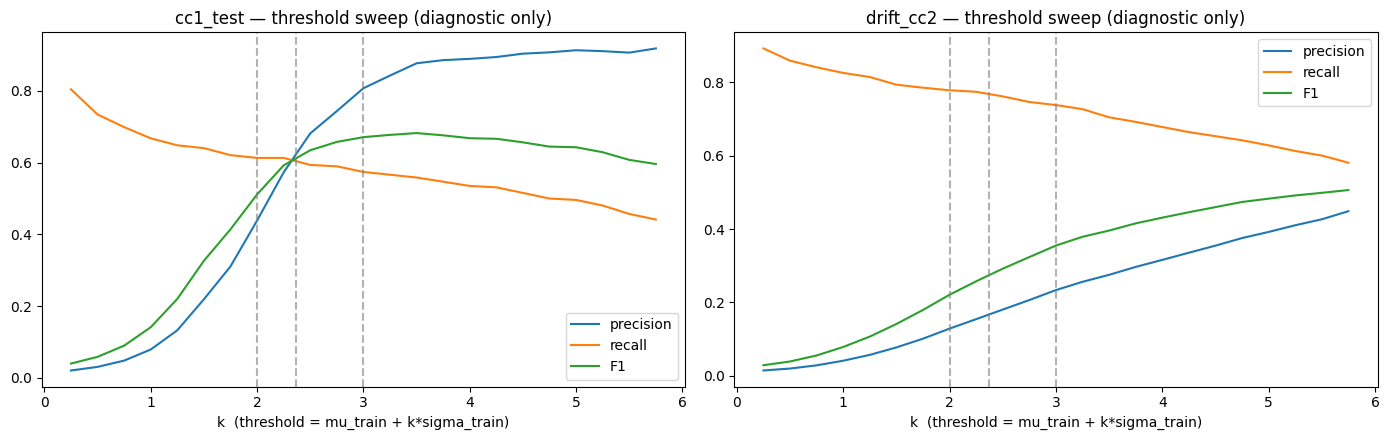

In [22]:
k_grid = np.arange(0.25, 6.0, 0.25)
sweep = {name: {'precision': [], 'recall': [], 'f1': []} for name in ALL_SETS}
for k in k_grid:
    t = meta['mu_train'] + k * meta['sigma_train']
    for name in ALL_SETS:
        pred = (mse[name] > t).astype(int)
        sweep[name]['precision'].append(precision_score(y[name], pred, zero_division=0))
        sweep[name]['recall'].append(recall_score(y[name], pred, zero_division=0))
        sweep[name]['f1'].append(f1_score(y[name], pred, zero_division=0))

fig, axes = plt.subplots(1, len(ALL_SETS), figsize=(7 * len(ALL_SETS), 4.5))
if len(ALL_SETS) == 1: axes = [axes]
for ax, name in zip(axes, ALL_SETS):
    ax.plot(k_grid, sweep[name]['precision'], label='precision')
    ax.plot(k_grid, sweep[name]['recall'], label='recall')
    ax.plot(k_grid, sweep[name]['f1'], label='F1')
    for tname, t in THRESHOLDS.items():
        k_equiv = (t - meta['mu_train']) / meta['sigma_train']
        ax.axvline(k_equiv, ls='--', color='gray', alpha=0.6)
    ax.set_xlabel('k  (threshold = mu_train + k*sigma_train)'); ax.set_title(f'{name} — threshold sweep (diagnostic only)')
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_cc1_eval_sweep.png'), dpi=120)
plt.show()

## Step 7 — Per-fault-type recall (with visualization)

Operating point: val_p99  (threshold=0.09799)

cc1_test     cpu            n=   88  recall=0.580
cc1_test     memory         n=   76  recall=0.763
cc1_test     pod-failure    n=   92  recall=0.500
drift_cc2    cpu            n=  207  recall=0.908
drift_cc2    memory         n=  414  recall=0.713
drift_cc2    pod-failure    n=   99  recall=0.737


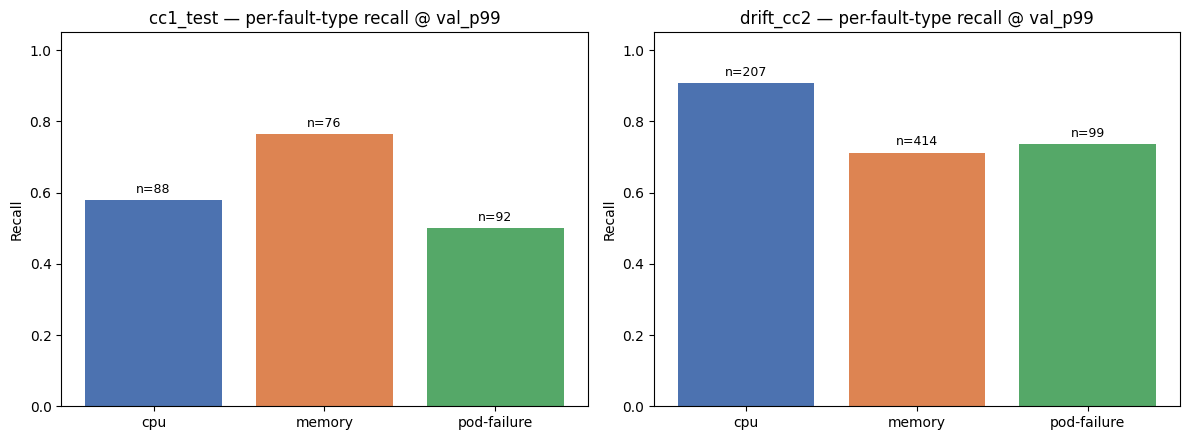

In [23]:
OP_POINT = 'val_p99'
t = THRESHOLDS[OP_POINT]
print(f'Operating point: {OP_POINT}  (threshold={t:.5f})\n')

per_fault_results = {}
for name in ALL_SETS:
    per_fault_results[name] = {}
    pred = (mse[name] > t).astype(int)
    for ftype in sorted({v for v in ft[name] if isinstance(v, str)}):
        mask = (ft[name] == ftype)
        n = int(mask.sum())
        rec = pred[mask].mean() if n > 0 else float('nan')
        per_fault_results[name][ftype] = {'n': n, 'recall': rec}
        print(f'{name:12s} {ftype:14s} n={n:5d}  recall={rec:.3f}')

fig, axes = plt.subplots(1, len(ALL_SETS), figsize=(6 * len(ALL_SETS), 4.5))
if len(ALL_SETS) == 1: axes = [axes]
for ax, name in zip(axes, ALL_SETS):
    ftypes = list(per_fault_results[name].keys())
    recalls = [per_fault_results[name][f]['recall'] for f in ftypes]
    ns = [per_fault_results[name][f]['n'] for f in ftypes]
    bars = ax.bar(ftypes, recalls, color=['#4C72B0', '#DD8452', '#55A868'][:len(ftypes)])
    for bar, n in zip(bars, ns):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'n={n}', ha='center', fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_ylabel('Recall'); ax.set_title(f'{name} — per-fault-type recall @ {OP_POINT}')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_cc1_eval_per_fault.png'), dpi=120)
plt.show()

## Step 8 — Detection delay

Time from fault **onset** (groundtruth timestamp) to the **first window
flagged** for that specific fault, at the `val_p99` threshold. Only computed
for `drift_cc2` (has real fault events with groundtruth timing available in
this notebook's scope) and only for detectable fault types (`cpu`, `memory`,
`pod-failure` — `delay`/`loss` are excluded from this module's scope, as
established in `clean_and_split.ipynb`).

In [24]:
GT_PATH = os.path.join(BASE, 'data', 'raw', 'Complex Case-2', 'Case-2', 'groundtruth', 'groundtruth.json')
with open(GT_PATH) as f:
    gt = json.load(f)
gt_df = pd.DataFrame(gt)
gt_df = gt_df[~gt_df['failure_type'].isin(['delay', 'loss'])].reset_index(drop=True)

df_cc2 = pd.read_csv(os.path.join(RAW_DIR, 'drift_complex_case2.csv'), low_memory=False)
df_cc2['is_gap'] = df_cc2['is_gap'].astype(bool)

WINDOW_SIZE = 30
pred_cc2 = (mse['drift_cc2'] > THRESHOLDS['val_p99']).astype(int)

# Rebuild windows with end-timestamp + cmdb_id, in the SAME construction order as windowing_pca.ipynb,
# so pred_cc2 (already computed, verified-consistent order) lines up with these timestamps index-for-index.
end_ts_list, cmdb_list = [], []
for cmdb_id, g in df_cc2.sort_values('timestamp').groupby('cmdb_id'):
    is_gap = g['is_gap'].values
    ts = g['timestamp'].values
    n = len(g)
    for i in range(0, n - WINDOW_SIZE + 1, 1):
        if is_gap[i:i + WINDOW_SIZE].any():
            continue
        end_ts_list.append(ts[i + WINDOW_SIZE - 1])
        cmdb_list.append(cmdb_id)
end_ts_arr = np.array(end_ts_list)
cmdb_arr = np.array(cmdb_list)
assert len(end_ts_arr) == len(pred_cc2), 'window count mismatch — cannot trust delay computation'

delays = []
for _, row in gt_df.iterrows():
    short_id = row['cmdb_id']
    full_id = f'observe.{short_id}'
    onset, duration = row['timestamp'], row['duration']
    mask = (cmdb_arr == full_id) & (end_ts_arr >= onset) & (end_ts_arr < onset + duration + WINDOW_SIZE * 15)
    if not mask.any():
        continue
    idx = np.where(mask)[0]
    idx_sorted = idx[np.argsort(end_ts_arr[idx])]
    flagged = idx_sorted[pred_cc2[idx_sorted] == 1]
    if len(flagged) == 0:
        delays.append({'cmdb_id': short_id, 'failure_type': row['failure_type'], 'detected': False, 'delay_sec': None})
    else:
        delay_sec = int(end_ts_arr[flagged[0]] - onset)
        delays.append({'cmdb_id': short_id, 'failure_type': row['failure_type'], 'detected': True, 'delay_sec': delay_sec})

delay_df = pd.DataFrame(delays)
print(delay_df.to_string(index=False))
print()
detected = delay_df[delay_df['detected']]
print(f'Detection rate: {len(detected)}/{len(delay_df)} events ({len(detected)/len(delay_df)*100:.0f}%)')
if len(detected):
    print(f'Mean delay: {detected["delay_sec"].mean():.0f}s ({detected["delay_sec"].mean()/60:.1f} min)')
    print(f'Median delay: {detected["delay_sec"].median():.0f}s ({detected["delay_sec"].median()/60:.1f} min)')
    print(f'By fault type:')
    print(detected.groupby('failure_type')['delay_sec'].agg(['mean', 'median', 'count']))

          cmdb_id failure_type  detected  delay_sec
       frontend-0       memory      True         75
       frontend-1       memory      True         75
       frontend-2       memory      True         75
currencyservice-0          cpu      True         75
currencyservice-1          cpu      True         60
currencyservice-2          cpu      True         90
    cartservice-0  pod-failure      True         75
    cartservice-1  pod-failure      True        135
    cartservice-2  pod-failure      True        135
       frontend-0       memory      True         75
       frontend-1       memory      True         90
       frontend-2       memory      True         90

Detection rate: 12/12 events (100%)
Mean delay: 88s (1.5 min)
Median delay: 75s (1.2 min)
By fault type:
               mean  median  count
failure_type                      
cpu            75.0    75.0      3
memory         80.0    75.0      6
pod-failure   115.0   135.0      3


## Step 9 — KS-test: does `drift_cc2` show real distributional shift?

In [25]:
ks_results = {}
ref = mse['cc1_train']
for name in DRIFT_SETS:
    normal_mse = mse[name][y[name] == 0]
    ks_stat, p_value = stats.ks_2samp(ref, normal_mse)
    verdict = 'REAL DRIFT (p<0.001)' if p_value < 0.001 else ('mild shift' if p_value < 0.05 else 'no significant shift')
    ks_results[name] = {'ks_stat': float(ks_stat), 'p_value': float(p_value)}
    print(f'{name:12s}  KS stat={ks_stat:.4f}  p-value={p_value:.2e}  {verdict}')

drift_cc2     KS stat=0.4097  p-value=0.00e+00  REAL DRIFT (p<0.001)


## Step 10 — MSE distribution plots (normal vs. anomaly), with both threshold and oracle marked

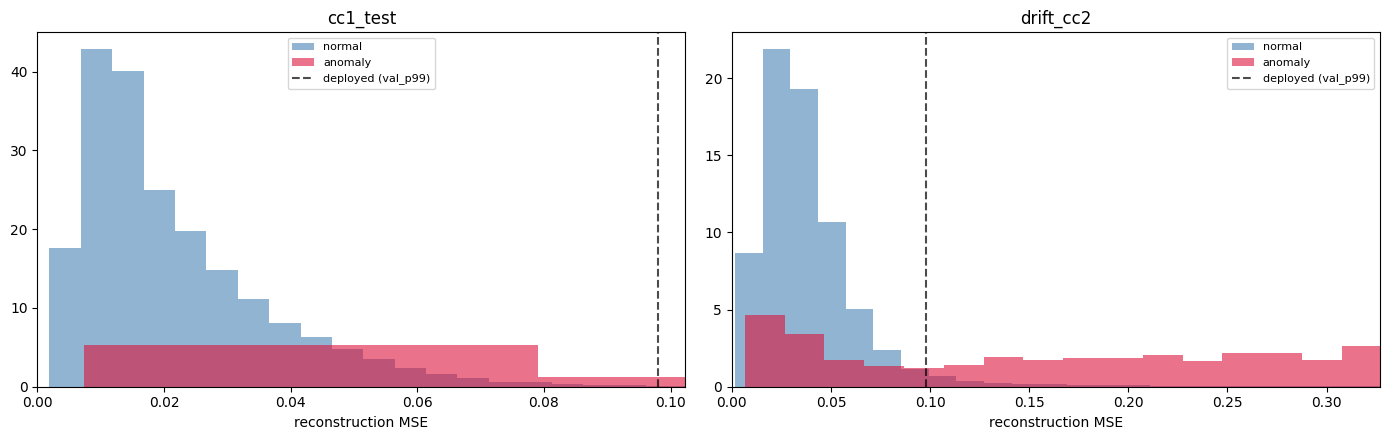

In [26]:
fig, axes = plt.subplots(1, len(ALL_SETS), figsize=(7 * len(ALL_SETS), 4.5))
if len(ALL_SETS) == 1: axes = [axes]
for ax, name in zip(axes, ALL_SETS):
    ax.hist(mse[name][y[name] == 0], bins=60, alpha=0.6, label='normal', density=True, color='steelblue')
    if (y[name] == 1).any():
        ax.hist(mse[name][y[name] == 1], bins=60, alpha=0.6, label='anomaly', density=True, color='crimson')
    ax.axvline(THRESHOLDS['val_p99'], ls='--', color='k', alpha=0.7, label='deployed (val_p99)')
    ax.set_title(name); ax.set_xlabel('reconstruction MSE'); ax.legend(fontsize=8)
    ax.set_xlim(0, np.percentile(mse[name], 99.5))
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_cc1_eval_distributions.png'), dpi=120)
plt.show()

## Step 11 — Consolidated summary dashboard (results-chapter-ready)

=== FINAL METRICS SUMMARY ===

           PR-AUC (primary)  ROC-AUC  F1 @ val_p99  Precision  Recall     FPR  Oracle-best F1
set                                                                                          
cc1_test             0.6014   0.8763        0.6175     0.6301  0.6055  0.0021          0.6857
drift_cc2            0.4089   0.8812        0.2757     0.1678  0.7722  0.0362          0.5147


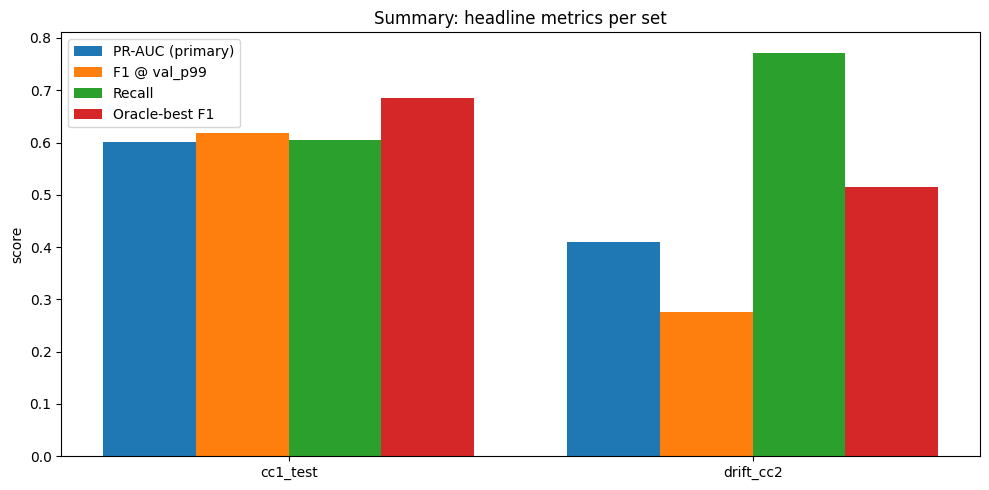

In [27]:
print('=== FINAL METRICS SUMMARY ===\n')
summary_rows = []
for name in ALL_SETS:
    row = {
        'set': name,
        'PR-AUC (primary)': auc_results[name]['auc_pr'],
        'ROC-AUC': auc_results[name]['auc_roc'],
        'F1 @ val_p99': pr_results[name]['val_p99']['f1'],
        'Precision': pr_results[name]['val_p99']['precision'],
        'Recall': pr_results[name]['val_p99']['recall'],
        'FPR': pr_results[name]['val_p99']['fpr'],
        'Oracle-best F1': oracle_results[name]['f1'],
    }
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows).set_index('set')
print(summary_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
metrics_to_plot = ['PR-AUC (primary)', 'F1 @ val_p99', 'Recall', 'Oracle-best F1']
x = np.arange(len(ALL_SETS)); width = 0.2
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, summary_df[metric], width, label=metric)
ax.set_xticks(x + width * 1.5); ax.set_xticklabels(ALL_SETS)
ax.set_ylabel('score'); ax.set_title('Summary: headline metrics per set')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_cc1_eval_summary_dashboard.png'), dpi=120)
plt.show()

## Step 12 — Save evaluation results

In [28]:
eval_results = {
    'thresholds': THRESHOLDS,
    'auc': auc_results,
    'precision_recall': pr_results,
    'oracle_ceiling': oracle_results,
    'per_fault_recall': per_fault_results,
    'detection_delay': delay_df.to_dict('records'),
    'ks_drift': ks_results,
    'operating_point': OP_POINT,
    'summary_table': summary_df.to_dict(),
}
eval_path = os.path.join(MODEL_DIR, 'vae_cc1_eval.pkl')
with open(eval_path, 'wb') as f:
    pickle.dump(eval_results, f)
print(f'Saved -> {eval_path}')

Saved -> c:\Users\jthar\Documents\Claude\Projects\module3\module3\models\vae_cc1_eval.pkl


## Summary

| Output | Contents |
|---|---|
| `models/vae_cc1_eval.pkl` | every metric computed in this notebook, incl. oracle-ceiling and detection delay |
| `vae_cc1_eval_pr_roc_curves.png` | PR curve (primary) + ROC curve, side by side |
| `vae_cc1_eval_sweep.png` | diagnostic threshold sweep |
| `vae_cc1_eval_per_fault.png` | per-fault-type recall bar chart |
| `vae_cc1_eval_distributions.png` | MSE histograms, normal vs. anomaly |
| `vae_cc1_eval_summary_dashboard.png` | consolidated headline-metrics bar chart |

**New in this rewrite** (previously missing): explicit PR-curve visualization,
FPR reported directly, oracle-ceiling analysis (was only ever done ad-hoc,
never saved to this notebook), detection-delay measurement (was flagged
repeatedly as a gap, never implemented until now), and the consolidated
summary dashboard matching the primary/supporting metrics framework agreed on
earlier in this project.